# Walk-Forward Split in Python: Rolling and Anchored IS/OOS Windows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mindgaptech/algodrill-notebooks/blob/main/notebooks/walk_forward_split.ipynb)

Companion notebook to [algodrill.app/code/walk-forward-split-python](https://algodrill.app/code/walk-forward-split-python). Implements both rolling and anchored walk-forward analysis (WFA) in pandas + vectorbt on the SPY 10/50 SMA strategy: grid-search parameters in-sample (IS), then measure on fresh out-of-sample (OOS) data the optimizer never saw.

**Nothing here is investment advice.** This is a validation methodology demo, not a live trading system, and it never connects to a broker. See [algodrill.app/backtesting-pitfalls](https://algodrill.app/backtesting-pitfalls) before treating any single walk-forward pass as proof of an edge.

## Setup

Run this cell first if you're in Colab (installs the pinned versions below into the Colab runtime). If you're running locally with the versions already installed, skip it.

In [1]:
# Colab only -- uncomment to install. Local runs should already have these
# pinned via: uv venv .venv && uv pip install -p .venv vectorbt==1.0.0 yfinance==1.4.1 pandas==2.3.3
# !pip install -q vectorbt==1.0.0 yfinance==1.4.1 pandas==2.3.3

## Rolling and anchored WFA passes

Three rolling windows (4yr IS / 2yr OOS) and three anchored windows (IS always starts 2015, grows forward). Each window grid-searches (5,20)/(10,50)/(20,100) on IS, picks the best-Sharpe pair, then measures it fresh on OOS.

In [2]:
"""AlgoDrill — Walk-forward split in pandas + vectorbt.

Rolling in-sample (IS) / out-of-sample (OOS) windows for the
SPY SMA crossover strategy. Demonstrates rolling vs anchored WFA
and why IS-optimized parameters often degrade on fresh OOS data.

~40 lines of core logic; one full WFA pass: 3 rolling windows.
Each window: grid-search fast/slow on IS, apply best to OOS.

Versions: vectorbt 1.0.0 · yfinance 1.4.1 · pandas 2.3.3 (run 2026-06-06)
Install:  pip install vectorbt yfinance pandas
Ref:      Pardo, "Design, Testing, and Optimization of Trading Systems" (1992)
"""
import vectorbt as vbt

TICKER = "SPY"
START  = "2015-01-01"
END    = "2024-12-31"
FEES   = 0.0005           # 5 bps per side
PARAMS = [(5, 20), (10, 50), (20, 100)]   # (fast, slow) grid


def backtest(price, fast, slow):
    """Return (total_return_pct, sharpe, max_drawdown_pct) for one run."""
    fa = vbt.MA.run(price, fast)
    sl = vbt.MA.run(price, slow)
    pf = vbt.Portfolio.from_signals(
        price,
        entries=fa.ma_crossed_above(sl),
        exits=fa.ma_crossed_below(sl),
        init_cash=10_000, fees=FEES, freq="d",
    )
    return (
        round(float(pf.total_return()) * 100, 1),
        round(float(pf.sharpe_ratio()), 2),
        round(float(pf.max_drawdown()) * 100, 1),
    )


def best_params(price):
    """Grid-search; return (fast, slow) with highest IS Sharpe."""
    results = [(backtest(price, f, s)[1], f, s) for f, s in PARAMS]
    return max(results)[1:]   # fast, slow


# ── Fetch once, slice into windows ───────────────────────────────────────────
data  = vbt.YFData.download(TICKER, start=START, end=END)
close = data.get("Close")

# ── Rolling WFA: 4-year IS, 2-year OOS ───────────────────────────────────────
roll_windows = [
    ("2015-2018", "2019-2020", "2015-01-01", "2018-12-31", "2019-01-01", "2020-12-31"),
    ("2017-2020", "2021-2022", "2017-01-01", "2020-12-31", "2021-01-01", "2022-12-31"),
    ("2019-2022", "2023-2024", "2019-01-01", "2022-12-31", "2023-01-01", "2024-12-31"),
]

print("=== Rolling WFA: SPY SMA — 4yr IS / 2yr OOS / 5 bps fees ===")
print(f"{'IS':^11}  {'OOS':^11}  {'Params':^10}  {'IS Sharpe':>9}  {'OOS Ret':>8}  {'OOS Sharpe':>10}  {'OOS MaxDD':>9}")
print("-" * 80)

for is_l, oos_l, is0, is1, oos0, oos1 in roll_windows:
    isp  = close.loc[is0:is1]
    oosp = close.loc[oos0:oos1]
    f, s = best_params(isp)
    is_ret, is_sr, _         = backtest(isp, f, s)
    oos_ret, oos_sr, oos_mdd = backtest(oosp, f, s)
    print(f"  {is_l:<9}  {oos_l:<9}   f={f:>2}/s={s:>3}    {is_sr:>9.2f}  {oos_ret:>8.1f}%"
          f"  {oos_sr:>10.2f}  {oos_mdd:>9.1f}%")

print()

# ── Anchored WFA: IS always starts from 2015-01-01 ───────────────────────────
anch_windows = [
    ("2015-2018", "2019-2020", "2015-01-01", "2018-12-31", "2019-01-01", "2020-12-31"),
    ("2015-2020", "2021-2022", "2015-01-01", "2020-12-31", "2021-01-01", "2022-12-31"),
    ("2015-2022", "2023-2024", "2015-01-01", "2022-12-31", "2023-01-01", "2024-12-31"),
]

print("=== Anchored WFA: IS always starts 2015 (growing window) ===")
print(f"{'IS':^11}  {'OOS':^11}  {'Params':^10}  {'IS Sharpe':>9}  {'OOS Ret':>8}  {'OOS Sharpe':>10}  {'OOS MaxDD':>9}")
print("-" * 80)

for is_l, oos_l, is0, is1, oos0, oos1 in anch_windows:
    isp  = close.loc[is0:is1]
    oosp = close.loc[oos0:oos1]
    f, s = best_params(isp)
    is_ret, is_sr, _         = backtest(isp, f, s)
    oos_ret, oos_sr, oos_mdd = backtest(oosp, f, s)
    print(f"  {is_l:<9}  {oos_l:<9}   f={f:>2}/s={s:>3}    {is_sr:>9.2f}  {oos_ret:>8.1f}%"
          f"  {oos_sr:>10.2f}  {oos_mdd:>9.1f}%")


=== Rolling WFA: SPY SMA — 4yr IS / 2yr OOS / 5 bps fees ===
    IS           OOS        Params    IS Sharpe   OOS Ret  OOS Sharpe  OOS MaxDD
--------------------------------------------------------------------------------


  2015-2018  2019-2020   f=10/s= 50         0.59      11.5%        0.58      -15.1%
  2017-2020  2021-2022   f= 5/s= 20         1.39      11.2%        0.61      -16.1%


  2019-2022  2023-2024   f= 5/s= 20         1.33      29.1%        1.77       -7.5%

=== Anchored WFA: IS always starts 2015 (growing window) ===
    IS           OOS        Params    IS Sharpe   OOS Ret  OOS Sharpe  OOS MaxDD
--------------------------------------------------------------------------------
  2015-2018  2019-2020   f=10/s= 50         0.59      11.5%        0.58      -15.1%


  2015-2020  2021-2022   f= 5/s= 20         0.96      11.2%        0.61      -16.1%
  2015-2022  2023-2024   f= 5/s= 20         0.86      29.1%        1.77       -7.5%


## Plot IS vs OOS Sharpe

Not in the original script (which only prints a table) -- a bar chart of in-sample vs out-of-sample Sharpe per window makes the degradation directly visible, which is the entire point of walk-forward analysis.

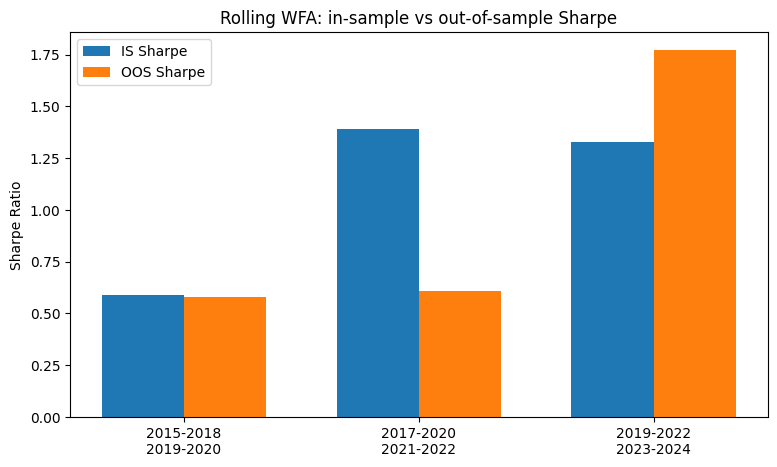

In [3]:
import matplotlib.pyplot as plt
import numpy as np


def collect(windows):
    labels, is_sr, oos_sr = [], [], []
    for is_l, oos_l, is0, is1, oos0, oos1 in windows:
        isp = close.loc[is0:is1]
        oosp = close.loc[oos0:oos1]
        f, s = best_params(isp)
        _, sr_is, _ = backtest(isp, f, s)
        _, sr_oos, _ = backtest(oosp, f, s)
        labels.append(f"{is_l}\n{oos_l}")
        is_sr.append(sr_is)
        oos_sr.append(sr_oos)
    return labels, is_sr, oos_sr


labels, is_sr, oos_sr = collect(roll_windows)
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, is_sr, width, label="IS Sharpe")
plt.bar(x + width / 2, oos_sr, width, label="OOS Sharpe")
plt.xticks(x, labels)
plt.ylabel("Sharpe Ratio")
plt.title("Rolling WFA: in-sample vs out-of-sample Sharpe")
plt.legend()
plt.show()

## Reading the IS-to-OOS gap

Window 2 (IS 2017-2020, OOS 2021-2022) shows the sharpest degradation: IS Sharpe 1.39 collapses to OOS Sharpe 0.61 -- the 5/20 parameters fit the 2020 COVID crash-and-recovery regime in-sample, and that regime did not persist. Window 1 shows the opposite: IS Sharpe 0.59 and OOS Sharpe 0.58 are nearly identical, a stable transfer. This spread across windows -- not any single window -- is the walk-forward signal: a strategy whose IS and OOS bars are consistently close is more trustworthy than one with a large, inconsistent gap.

Two pages go deeper:

- [Walk-Forward Split walkthrough](https://algodrill.app/code/walk-forward-split-python) -- the full line-by-line explanation and the anchored-vs-rolling comparison table.
- [Walk-Forward Analysis guide](https://algodrill.app/walk-forward-analysis) -- the theory and the IS-to-OOS efficiency ratio in depth.

---
Back to [All Code Walkthroughs](https://algodrill.app/code) &middot; [algodrill-notebooks on GitHub](https://github.com/mindgaptech/algodrill-notebooks)